### 1. Introduction to Libraries

- **NumPy**: Efficient numerical computations and array operations. Many scikit-learn and PyTorch tensors start from NumPy arrays.
- **pandas**: Loading, cleaning, and transforming the IBM telecom churn dataset. Used for feature engineering, encoding, and joining new features such as VAE latents or GAN-generated samples.
- **scikit-learn**: Traditional ML models (Logistic Regression, Random Forest, XGBoost wrapper), preprocessing utilities, train–test splits, SMOTE, and evaluation metrics (accuracy, precision, recall, F1, ROC-AUC).
- **PyTorch**: Used to implement all neural network models (VAE and GAN). Handles model definition, GPU acceleration, backpropagation, and optimizers.  
- **Matplotlib (and optionally Seaborn)**: Visualizations for training curves, feature importance, and latent-space embeddings.
- **XGBoost (Python API)**: High-performance gradient boosting classifier used in the comparative experiments.


In [20]:
!pip install imbalanced-learn xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
from sklearn.tree import plot_tree

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#### Target and Missing Values
we sanity-check the dataset before modeling:

- inspect the **Churn** distribution and churn rate to understand class imbalance
- check for missing values in each column so we can decide how to handle them
- print basic summary statistics for numerical features (mean, std, min, max)

needed to know whether we need resampling (e.g., SMOTE) and how clean the raw data is.


In [21]:
# updated the dataset to this, i couldn't find the exact one that you were referencing
# this one is pretty comprehensive
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("shape:", df.shape)
print("\columns:")
print(df.dtypes)
df.head()

shape: (7043, 21)
\columns:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Check for any missing values in the dataset, basic summary stuff

In [22]:
print("target variable distribution:")
print(df['Churn'].value_counts())
print("\nchurn Rate:", df['Churn'].value_counts(normalize=True))

# check for missing values
print("\n missing Values:")
missing_vals = df.isnull().sum()
if missing_vals.sum() == 0:
    print("no missing values")
else:
    print(missing_vals[missing_vals > 0])

# Basic statistics
print("\nnumerical features:")
df.describe()

target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

churn Rate: Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

 missing Values:
no missing values

numerical features:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Preprocessing & Feature Engineering

this function builds a reusable preprocessing pipeline for the telecom dataset:

- converts `TotalCharges` to numeric and fills missing values using `MonthlyCharges`.
- creates additional features such as:
  - `AvgChargesPerTenure` (average monthly charges over tenure),
  - `CustomerValue` (tenure × monthly charges),
  - `NumAddOnServices`, `HasInternet`, `HasPhone`, and `TotalServices`.
- encodes simple binary features (e.g., `gender`, `Partner`, `Dependents`) into 0/1.
- maps `Contract` to an ordinal level and converts `Churn` to a binary target.

this step is essential because it standardizes the raw dataset into a numerical, model-ready format and adds domain-informed features.


In [23]:
def preprocess_telecom_data(df):
    """
    Comprehensive preprocessing pipeline for telecom churn data
    """
    # make a copy so we don't mess up original data
    data = df.copy()

    # convert TotalCharges to numeric value if its a string
    data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
    data['TotalCharges'].fillna(data['MonthlyCharges'], inplace=True) # is missing then populate with monthly

    # adding some useful feature calculations

    # avg charges/mo of tenure
    data['AvgChargesPerTenure'] = data['TotalCharges'] / (data['tenure'] + 1)

    # customer lifetime value
    data['CustomerValue'] = data['tenure'] * data['MonthlyCharges']

    # customer has internet services
    data['HasInternet'] = (data['InternetService'] != 'No').astype(int)

    # number of services customer is subscribed to
    service_cols = ['OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    data['NumAddOnServices'] = 0
    for col in service_cols:
        if col in data.columns:
            data['NumAddOnServices'] += (data[col] == 'Yes').astype(int)

    # has phone service
    data['HasPhone'] = (data['PhoneService'] == 'Yes').astype(int)

    # total services count
    data['TotalServices'] = data['NumAddOnServices'] + data['HasInternet'] + data['HasPhone']

    # contract length
    contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    data['ContractLevel'] = data['Contract'].map(contract_map)

    # encode the binary features
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        if col in data.columns:
            data[col] = (data[col] == 'Yes').astype(int) if col != 'gender' else (data[col] == 'Male').astype(int)

    # encode the target var (churn)
    data['Churn'] = (data['Churn'] == 'Yes').astype(int)

    print(f"{len(data.columns) - len(df.columns)} new features created")

    return data

df_processed = preprocess_telecom_data(df)
print("\n processed dataframe shape:", df_processed.shape)

7 new features created

 processed dataframe shape: (7043, 28)


### Encoding Categorical Features and Building Feature/Target Matrices

gere we transform the preprocessed DataFrame into pure numeric features suitable for models:

- confirm that `Churn` is already encoded as 0/1.
- convert binary columns (e.g., `gender`, `Partner`, `PhoneService`) to 0/1
- one-hot encode multi-category fields such as `InternetService`, `MultipleLines`, `Contract`, and `PaymentMethod`
- drop non-feature identifiers like `customerID`
- force all remaining columns to numeric and fill any residual `NaN`s with 0
- finally, split into:
  - `X`: feature matrix (all predictors)
  - `y`: target vector (`Churn`)


In [24]:
# making another copy for encoding
df_encoded = df_processed.copy()

# check churn column - it's already encoded!
print("churn column type:", df_encoded['Churn'].dtype)
print("churn values:", df_encoded['Churn'].value_counts())
print("churn rate:", df_encoded['Churn'].mean())

# churn is already 0/1, so we don't need to encode it

# encode other binary features
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col == 'gender':
        df_encoded[col] = (df_encoded[col] == 'Male').astype(int)
    else:
        df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# multiple lines handling
df_encoded['MultipleLines_Yes'] = (df_encoded['MultipleLines'] == 'Yes').astype(int)
df_encoded['MultipleLines_No'] = (df_encoded['MultipleLines'] == 'No').astype(int)
df_encoded = df_encoded.drop('MultipleLines', axis=1)

# handle different internet services - add dtype=int to ensure numeric
internet_dummies = pd.get_dummies(df_encoded['InternetService'], prefix='Internet', dtype=int)
df_encoded = pd.concat([df_encoded, internet_dummies], axis=1)
df_encoded = df_encoded.drop('InternetService', axis=1)

# handle service columns w/ "no internet service"
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    # binary conversion
    df_encoded[col + '_Yes'] = (df_encoded[col] == 'Yes').astype(int)
    df_encoded = df_encoded.drop(col, axis=1)

# encode categorical columns (one-hot) - add dtype=int to ensure numeric
categorical_cols = ['Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=False, dtype=int)

# customer_id is not a feature
if 'customerID' in df_encoded.columns:
    df_encoded = df_encoded.drop('customerID', axis=1)

# ensure all columns are numeric
for col in df_encoded.columns:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

# check for nan values
if df_encoded.isnull().any().any():
    print("\nwarning: nan values found after conversion")
    print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])
    df_encoded = df_encoded.fillna(0)

# separate features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("\nfeature matrix shape:", X.shape)
print("target shape:", y.shape)
print("\nclass distribution:")
print(y.value_counts())
print("\nclass proportions:")
print(y.value_counts(normalize=True))

print(f"\ntotal features: {X.shape[1]}")

# check data types to ensure all are numeric
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"\nnon-numeric columns found: {non_numeric}")
else:
    print("\nall columns are numeric - ready for modeling!")

# show churn statistics
print(f"\nchurn rate: {y.mean():.2%}")
print(f"no churn: {(y==0).sum()} customers")
print(f"churn: {(y==1).sum()} customers")

churn column type: int64
churn values: Churn
0    5174
1    1869
Name: count, dtype: int64
churn rate: 0.2653698707936959

feature matrix shape: (7043, 34)
target shape: (7043,)

class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

class proportions:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

total features: 34

all columns are numeric - ready for modeling!

churn rate: 26.54%
no churn: 5174 customers
churn: 1869 customers


In [25]:
#split data for train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("training set size:", X_train.shape)
print("test set size:", X_test.shape)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# converting back to dataframe for easier processing
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\ndata is split into test/train")

training set size: (5634, 34)
test set size: (1409, 34)

data is split into test/train


### Handling Class Imbalance with SMOTE

to fix the skewed churn distribution, we apply **SMOTE** (Synthetic Minority Oversampling Technique) on the training set:

- generate synthetic minority-class (churn) samples in feature space
- produce a more balanced training distribution without touching the test set
- print class counts and proportions before and after SMOTE to verify the effect


In [26]:
# apply smote to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("original training set class distribution:")
print(y_train.value_counts())
print("\noriginal class proportions:")
print(y_train.value_counts(normalize=True))

print("\nafter smote class distribution:")
print(pd.Series(y_train_balanced).value_counts())
print("\nafter smote class proportions:")
print(pd.Series(y_train_balanced).value_counts(normalize=True))

print(f"\ntraining samples increased from {len(y_train)} to {len(y_train_balanced)}")
print(f"synthetic samples created: {len(y_train_balanced) - len(y_train)}")

original training set class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

original class proportions:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

after smote class distribution:
Churn
0    4139
1    4139
Name: count, dtype: int64

after smote class proportions:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64

training samples increased from 5634 to 8278
synthetic samples created: 2644



in this section we:

- initialize a suite of standard classifiers (logistic regression, decision tree, random forest, gradient boosting, XGBoost, SVM)
- train each model on the balanced data (from smote) training data
- evaluate on the original test set using accuracy, precision, recall, F1-score, and ROC-AUC
- aggregate results into a DataFrame and identify the best model under different metrics

In [27]:
# initialize all models
models = {
    'regression': LogisticRegression(random_state=42, max_iter=1000),
    'decision tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'random forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'gradient boost': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'xgboost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'svm': SVC(random_state=42, probability=True, kernel='rbf')
}

# train models and store results
results = {}
trained_models = {}

print("training models\n")
for name, model in models.items():
    print(f"training {name}")

    # train on balanced data
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model

    # predict on test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # calculate metrics
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 'N/A'
    }
    print(f"{name} complete\n")

# display results as dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("\nmodel performance comparison:")
print(results_df)

# find best model
best_model_f1 = results_df['f1-score'].idxmax()
best_model_auc = results_df['ROC-AUC'].idxmax()
print(f"\nbest model by f1 score: {best_model_f1} ({results_df.loc[best_model_f1, 'f1-score']:.4f})")
print(f"best model by roc-auc: {best_model_auc} ({results_df.loc[best_model_auc, 'ROC-AUC']:.4f})")

training models

training regression
regression complete

training decision tree
decision tree complete

training random forest
random forest complete

training gradient boost
gradient boost complete

training xgboost
xgboost complete

training svm
svm complete


model performance comparison:
                accuracy  precision  recall  f1-score  ROC-AUC
regression        0.7495     0.5184  0.7914    0.6265   0.8472
decision tree     0.7282     0.4924  0.7754    0.6023   0.8301
random forest     0.7644     0.5502  0.6150    0.5808   0.8159
gradient boost    0.7693     0.5483  0.7433    0.6311   0.8407
xgboost           0.7715     0.5625  0.6257    0.5924   0.8220
svm               0.7495     0.5197  0.7406    0.6108   0.8144

best model by f1 score: gradient boost (0.6311)
best model by roc-auc: regression (0.8472)


here is the definition of the VAE thjat can be used for the data that we have

- the encoder maps the input feature vector into a latent mean and log-variance.
- the **reparameterization** step samples a latent vector using the mean and variance (enabling backpropagation)
- the **decoder** reconstructs the original feature vector from the latent representation
- the **VAE loss** combines:
  - reconstruction loss (MSE between input and reconstruction),
  - KL divergence regularization to keep the latent space well-behaved
- `get_latent_representation` helper returns the mean of the latent distribution for downstream tasks

this is what we use to learn the compressed representation of the customer


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# check if cuda is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

class TelecomVAE(nn.Module):
    """
    vae for learning latent representations of telecom customers
    """
    def __init__(self, input_dim, latent_dim=10, hidden_dim=128):
        super(TelecomVAE, self).__init__()

        # encoder - add more layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc1b = nn.Linear(hidden_dim, hidden_dim)  # NEW layer
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # decoder - mirror structure
        self.fc3 = nn.Linear(latent_dim, hidden_dim // 2)
        self.fc4 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.fc4b = nn.Linear(hidden_dim, hidden_dim)  # NEW layer
        self.fc5 = nn.Linear(hidden_dim, input_dim)

        self.dropout = nn.Dropout(0.2)

    def encode(self, x):
        # encode input to latent space parameters
        h = F.relu(self.fc1(x))
        h = self.dropout(h)
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # reparameterization trick for backprop
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        # decode from latent space
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        reconstruction = torch.sigmoid(self.fc5(h))
        return reconstruction

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

    def get_latent_representation(self, x):
        # extract latent features for downstream tasks
        mu, _ = self.encode(x)
        return mu

# vae loss function
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    """
    vae loss = reconstruction loss + kl divergence
    beta controls the weight of kl divergence (beta-vae)
    """
    # reconstruction loss (mse for continuous features)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # kl divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss

print("vae architecture defined successfully")

using device: cuda
vae architecture defined successfully


this is where we train the VAE

- convert scaled feature matrices into PyTorch tensors and wrap them in `DataLoader`s.
- initialize the VAE with a chosen latent dimension (e.g., 20)
- use Adam optimizer with a small learning rate (0.001)
- train for 500 epochs (originally 150, but scaled up), computing the VAE loss on each batch
- track and plot the training loss over epochs to verify that the model is actually learning.

hyperparameters:
- **latent_dim = 20**
- **batch_size = 128**
- **num_epochs = 500**
- **beta = 0.1**

training vae
epoch [10/500], loss: 22.6798
epoch [20/500], loss: 20.8686
epoch [30/500], loss: 19.6194
epoch [40/500], loss: 19.2178
epoch [50/500], loss: 18.9798
epoch [60/500], loss: 18.7175
epoch [70/500], loss: 18.5763
epoch [80/500], loss: 18.4529
epoch [90/500], loss: 18.3395
epoch [100/500], loss: 18.2506
epoch [110/500], loss: 18.2077
epoch [120/500], loss: 18.1361
epoch [130/500], loss: 18.0999
epoch [140/500], loss: 18.0365
epoch [150/500], loss: 18.0317
epoch [160/500], loss: 17.9876
epoch [170/500], loss: 17.9816
epoch [180/500], loss: 17.9584
epoch [190/500], loss: 17.7918
epoch [200/500], loss: 17.7526
epoch [210/500], loss: 17.7415
epoch [220/500], loss: 17.7038
epoch [230/500], loss: 17.6987
epoch [240/500], loss: 17.6689
epoch [250/500], loss: 17.6520
epoch [260/500], loss: 17.6119
epoch [270/500], loss: 17.6338
epoch [280/500], loss: 17.6104
epoch [290/500], loss: 17.5983
epoch [300/500], loss: 17.5891
epoch [310/500], loss: 17.1866
epoch [320/500], loss: 17.1608
epoc

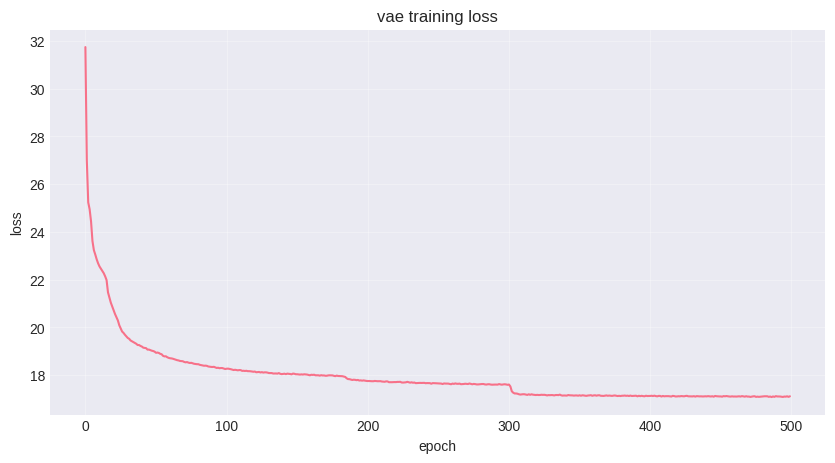

In [29]:
# prepare data for pytorch
X_train_tensor = torch.FloatTensor(X_train_scaled.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled.values).to(device)

# create dataloaders
train_dataset = TensorDataset(X_train_tensor, torch.FloatTensor(y_train.values))
test_dataset = TensorDataset(X_test_tensor, torch.FloatTensor(y_test.values))

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# initialize vae
input_dim = X_train_scaled.shape[1]
latent_dim = 20  # compress to 10 latent features
vae = TelecomVAE(input_dim, latent_dim).to(device)

# setup training
optimizer = optim.Adam(vae.parameters(), lr=0.001)
num_epochs = 500

# training loop
print("training vae")
train_losses = []

for epoch in range(num_epochs):
    vae.train()
    train_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()

        # forward pass
        recon_batch, mu, logvar = vae(data)

        # calculate loss
        loss = vae_loss_function(recon_batch, data, mu, logvar, beta=0.1)

        # backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # average loss for epoch
    avg_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'epoch [{epoch+1}/{num_epochs}], loss: {avg_loss:.4f}')

print("vae training complete")

# plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('vae training loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True, alpha=0.3)
plt.show()


once the VAE is trained, we:

- switch to evaluation mode and pass the entire train/test feature matrices through the encoder
- collect the latent means into new DataFrames `X_train_latent` and `X_test_latent`
- compare dimensionality before and after compression
- optionally **combine** original scaled features with the latent features to form `X_train_combined` and `X_test_combined`

this lets us test two things:
1. using only VAE latent features as compressed inputs
2. augmenting original features with deep learned representations


In [30]:
# extract latent representations for downstream classification
vae.eval()
with torch.no_grad():
    # get latent features for training data
    train_latent = vae.get_latent_representation(X_train_tensor).cpu().numpy()
    test_latent = vae.get_latent_representation(X_test_tensor).cpu().numpy()

# create dataframes for latent features
latent_columns = [f'latent_{i}' for i in range(latent_dim)]
X_train_latent = pd.DataFrame(train_latent, columns=latent_columns, index=X_train.index)
X_test_latent = pd.DataFrame(test_latent, columns=latent_columns, index=X_test.index)

print(f"original feature dimensions: {X_train_scaled.shape[1]}")
print(f"latent feature dimensions: {X_train_latent.shape[1]}")
print(f"compression ratio: {X_train_scaled.shape[1] / X_train_latent.shape[1]:.1f}x")

# combine original features with latent features
X_train_combined = pd.concat([X_train_scaled, X_train_latent], axis=1)
X_test_combined = pd.concat([X_test_scaled, X_test_latent], axis=1)

print(f"\ncombined feature dimensions: {X_train_combined.shape[1]}")

original feature dimensions: 34
latent feature dimensions: 20
compression ratio: 1.7x

combined feature dimensions: 54


define a conditional GAN for tabular data:

- the **Generator** takes:
  - Random noise,
  - (Optionally) a churn label,
  and outputs synthetic feature vectors in a `tanh`-scaled range [-1, 1].
- the **Discriminator** takes:
  - either real or fake samples,
  - the corresponding label,
  and outputs a probability of "realness"

conditioning on labels lets the GAN specifically learn the distribution of churned customers


In [31]:
class Generator(nn.Module):
    """
    generator network for creating synthetic customer data
    """
    def __init__(self, noise_dim, output_dim, conditional=True):
        super(Generator, self).__init__()
        self.conditional = conditional

        # if conditional, we add label information
        input_dim = noise_dim + 1 if conditional else noise_dim

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, output_dim),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, noise, labels=None):
        if self.conditional and labels is not None:
            # concatenate noise with label
            input_data = torch.cat([noise, labels], dim=1)
        else:
            input_data = noise
        return self.model(input_data)

class Discriminator(nn.Module):
    """
    discriminator network for distinguishing real vs synthetic data
    """
    def __init__(self, input_dim, conditional=True):
        super(Discriminator, self).__init__()
        self.conditional = conditional

        # if conditional, we add label information
        model_input_dim = input_dim + 1 if conditional else input_dim

        self.model = nn.Sequential(
            nn.Linear(model_input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, data, labels=None):
        if self.conditional and labels is not None:
            # concatenate data with label
            input_data = torch.cat([data, labels], dim=1)
        else:
            input_data = data
        return self.model(input_data)

print("gan architecture defined successfully")

gan architecture defined successfully


this block trains the GAN to model churned-customer feature distributions:

- filter the training set to only churned customers
- normalize features into [-1, 1] to match the Generator’s `tanh` output.
- Train with:
  - label smoothing (real targets ~0.9, fake ~0.1),
  - noisy inputs to the Discriminator,
  - less frequent Discriminator updates to avoid overpowering the Generator
- track losses over epochs and plot both the raw losses and their ratio



training conditional gan
epoch [20/150], d_loss: 1.1572, g_loss: 0.7511
epoch [40/150], d_loss: 1.0063, g_loss: 0.8560
epoch [60/150], d_loss: 0.7999, g_loss: 1.3184
epoch [80/150], d_loss: 0.7947, g_loss: 1.4068
epoch [100/150], d_loss: 0.7466, g_loss: 1.7273
epoch [120/150], d_loss: 0.7117, g_loss: 2.0000
epoch [140/150], d_loss: 0.6813, g_loss: 1.9854
gan training complete


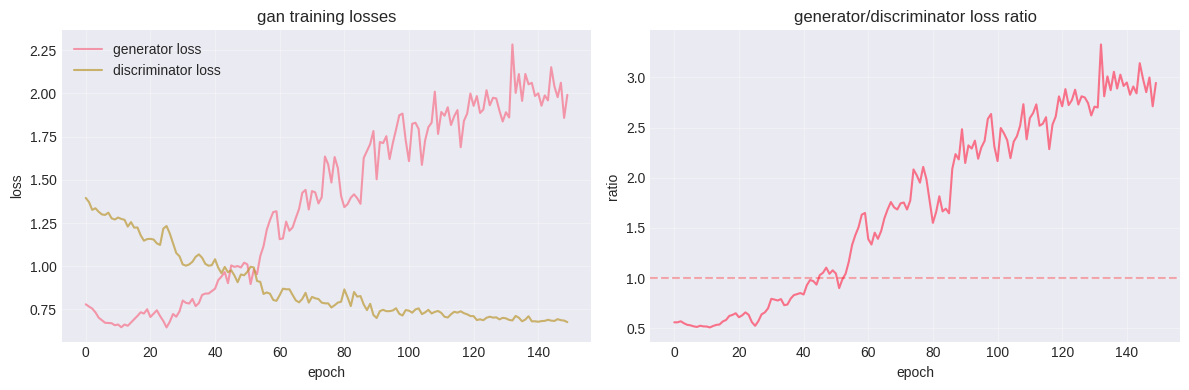

In [32]:
# prepare churned customer data for gan training
churned_indices = y_train == 1
X_train_churned = X_train_scaled[churned_indices]
y_train_churned = y_train[churned_indices]

# normalize data to [-1, 1] for gan
X_train_normalized = 2 * X_train_scaled - 1
X_train_churned_normalized = 2 * X_train_churned - 1

# convert to tensors
X_churned_tensor = torch.FloatTensor(X_train_churned_normalized.values).to(device)
y_churned_tensor = torch.FloatTensor(y_train_churned.values).unsqueeze(1).to(device)

# initialize gan
noise_dim = 100
generator = Generator(noise_dim, input_dim, conditional=True).to(device)
discriminator = Discriminator(input_dim, conditional=True).to(device)

# optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0001)

# loss function
criterion = nn.BCELoss()

# training parameters
num_epochs_gan = 150
batch_size_gan = 64

# create dataloader for churned customers
churned_dataset = TensorDataset(X_churned_tensor, y_churned_tensor)
churned_loader = DataLoader(churned_dataset, batch_size=batch_size_gan, shuffle=True)

# training loop with fixes for stability
print("training conditional gan")
g_losses = []
d_losses = []

for epoch in range(num_epochs_gan):
    for i, (real_data, labels) in enumerate(churned_loader):
        batch_size_current = real_data.size(0)

        # label smoothing - soften the targets
        real_labels = torch.ones(batch_size_current, 1).to(device) * 0.9  # was 1.0
        fake_labels = torch.ones(batch_size_current, 1).to(device) * 0.1  # was 0.0

        # train discriminator only every 2 iterations (let generator catch up)
        if i % 2 == 0:
            # train discriminator
            d_optimizer.zero_grad()

            # real data with small noise
            real_data_noisy = real_data + torch.randn_like(real_data) * 0.05
            d_real_output = discriminator(real_data_noisy, labels)
            d_real_loss = criterion(d_real_output, real_labels)

            # fake data
            noise = torch.randn(batch_size_current, noise_dim).to(device)
            fake_data = generator(noise, labels)
            fake_data_noisy = fake_data.detach() + torch.randn_like(fake_data) * 0.05
            d_fake_output = discriminator(fake_data_noisy, labels)
            d_fake_loss = criterion(d_fake_output, fake_labels)

            # total discriminator loss
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()

        # always train generator
        g_optimizer.zero_grad()

        # generate fake data again
        noise = torch.randn(batch_size_current, noise_dim).to(device)
        fake_data = generator(noise, labels)
        d_fake_output = discriminator(fake_data, labels)

        # generator tries to fool discriminator
        g_loss = criterion(d_fake_output, real_labels)
        g_loss.backward()
        g_optimizer.step()

    # store losses
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'epoch [{epoch+1}/{num_epochs_gan}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}')

print("gan training complete")

# plot gan training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(g_losses, label='generator loss', alpha=0.7)
axes[0].plot(d_losses, label='discriminator loss', alpha=0.7)
axes[0].set_title('gan training losses')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot loss ratio
loss_ratio = np.array(g_losses) / (np.array(d_losses) + 1e-8)
axes[1].plot(loss_ratio)
axes[1].set_title('generator/discriminator loss ratio')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('ratio')
axes[1].axhline(y=1, color='r', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

once the GAN is trained, we use the Generator to:

- compute how many churned samples are needed to match the non-churn class
- generate that many synthetic churned customers in batches using random noise + churn label = 1
- denormalize the features back to [0, 1]
- append synthetic churned rows to the original training data to form `X_train_gan_balanced` and `y_train_gan_balanced`


In [33]:
# generate synthetic churned customers to balance dataset
num_samples_needed = len(y_train[y_train == 0]) - len(y_train[y_train == 1])
print(f"generating {num_samples_needed} synthetic churned customers")

generator.eval()
with torch.no_grad():
    # generate samples in batches
    synthetic_samples = []
    batch_size_gen = 100

    for i in range(0, num_samples_needed, batch_size_gen):
        current_batch_size = min(batch_size_gen, num_samples_needed - i)

        # generate noise
        noise = torch.randn(current_batch_size, noise_dim).to(device)

        # create churn labels (1 for churned)
        churn_labels = torch.ones(current_batch_size, 1).to(device)

        # generate synthetic data
        synthetic_batch = generator(noise, churn_labels).cpu().numpy()
        synthetic_samples.append(synthetic_batch)

    # combine all synthetic samples
    synthetic_data = np.vstack(synthetic_samples)

    # denormalize back to [0, 1]
    synthetic_data = (synthetic_data + 1) / 2

# create synthetic dataframecl
synthetic_df = pd.DataFrame(synthetic_data, columns=X_train_scaled.columns)
synthetic_labels = np.ones(len(synthetic_df))

print(f"generated {len(synthetic_df)} synthetic samples")
print(f"synthetic data shape: {synthetic_df.shape}")

# combine original and synthetic data
X_train_gan_balanced = pd.concat([X_train_scaled, synthetic_df], axis=0).reset_index(drop=True)
y_train_gan_balanced = pd.concat([y_train, pd.Series(synthetic_labels)], axis=0).reset_index(drop=True)

print(f"\nbalanced dataset with gan:")
print(f"total samples: {len(y_train_gan_balanced)}")
print(f"class distribution:\n{y_train_gan_balanced.value_counts()}")

generating 2644 synthetic churned customers
generated 2644 synthetic samples
synthetic data shape: (2644, 34)

balanced dataset with gan:
total samples: 8278
class distribution:
0.0    4139
1.0    4139
Name: count, dtype: int64


here we build a comparison across five data representations:

- **original**: imbalanced data as-is
- **smote**: balanced with SMOTE.
- **vae_latent**: only VAE latent features
- **vae_combined**: original + VAE latent features
- **gan_synthetic**: balanced using GAN-generated churners

for each approach, we train three core models (Logistic Regression, Random Forest, XGBoost) and record accuracy, precision, recall, F1, and ROC-AUC on the same test set


In [34]:
# create different training sets for comparison
training_sets = {
    'original': (X_train_scaled, y_train),
    'smote': (X_train_balanced, y_train_balanced),
    'vae_latent': (X_train_latent, y_train),
    'vae_combined': (X_train_combined, y_train),
    'gan_synthetic': (X_train_gan_balanced, y_train_gan_balanced)
}

# create different test sets
test_sets = {
    'original': (X_test_scaled, y_test),
    'smote': (X_test_scaled, y_test),
    'vae_latent': (X_test_latent, y_test),
    'vae_combined': (X_test_combined, y_test),
    'gan_synthetic': (X_test_scaled, y_test)
}

# train models on different representations
comparison_results = {}

for approach_name, (X_train_approach, y_train_approach) in training_sets.items():
    print(f"\ntraining models with {approach_name} approach")

    X_test_approach, y_test_approach = test_sets[approach_name]
    approach_results = {}

    # train subset of models for comparison
    models_to_compare = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    }

    for model_name, model in models_to_compare.items():
        # train model
        model.fit(X_train_approach, y_train_approach)

        # predict
        y_pred = model.predict(X_test_approach)
        y_pred_proba = model.predict_proba(X_test_approach)[:, 1]

        # calculate metrics
        approach_results[model_name] = {
            'accuracy': accuracy_score(y_test_approach, y_pred),
            'precision': precision_score(y_test_approach, y_pred),
            'recall': recall_score(y_test_approach, y_pred),
            'f1': f1_score(y_test_approach, y_pred),
            'roc_auc': roc_auc_score(y_test_approach, y_pred_proba)
        }

    comparison_results[approach_name] = approach_results


training models with original approach

training models with smote approach

training models with vae_latent approach

training models with vae_combined approach

training models with gan_synthetic approach


here, we visualize all of the results

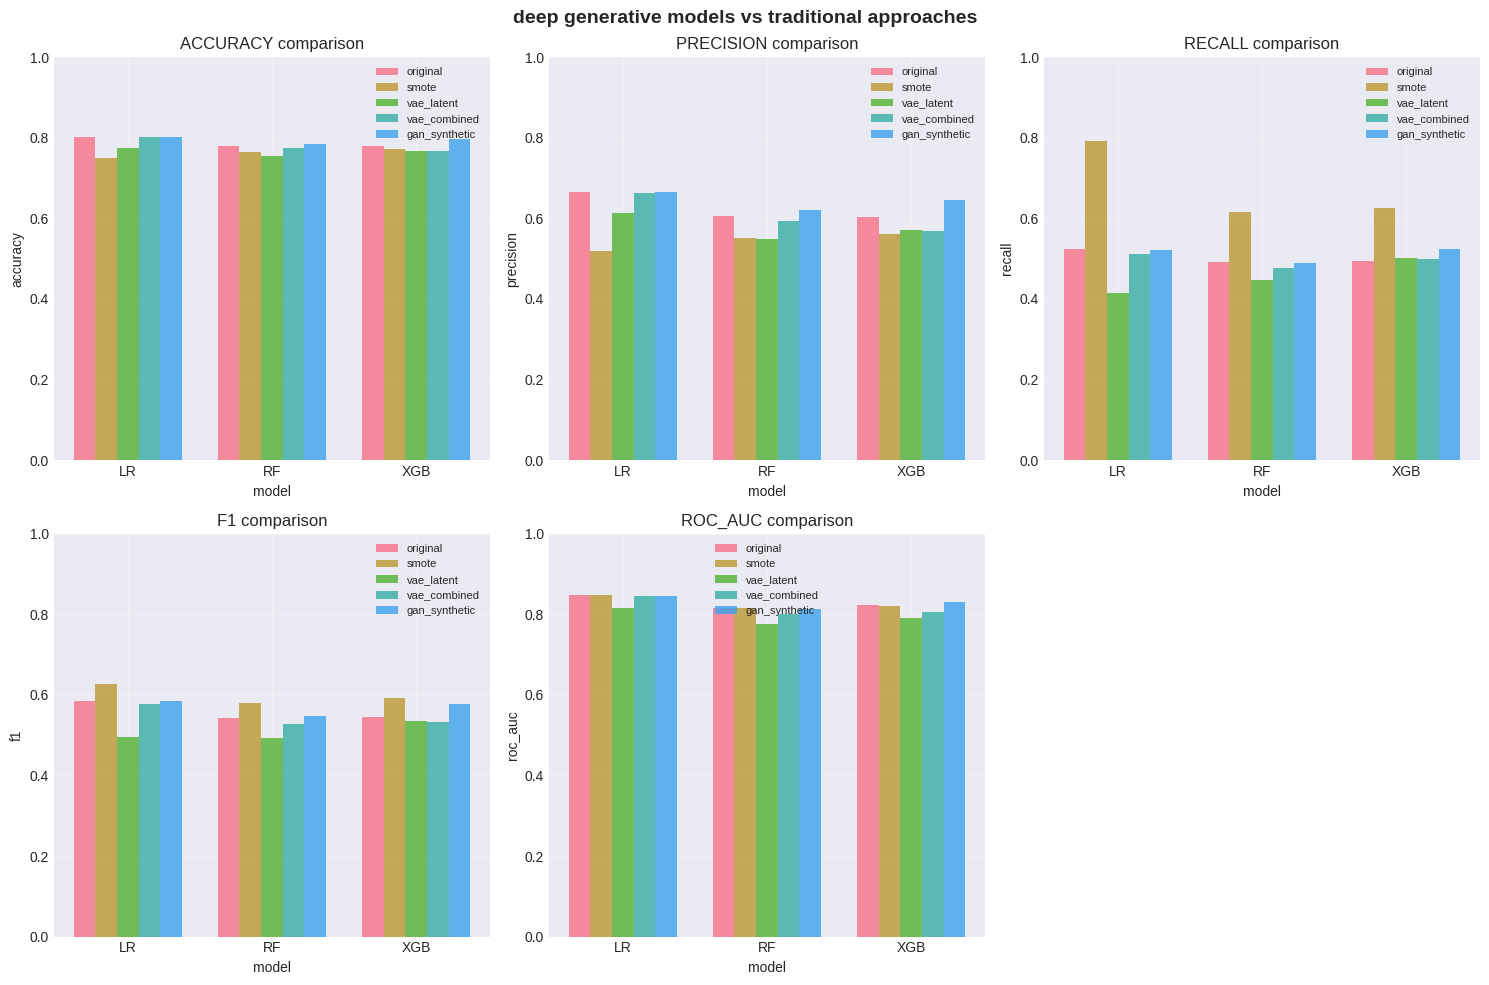


detailed results table:
         approach                model  accuracy  precision  recall      f1  \
0        original  Logistic Regression    0.8034     0.6644  0.5241  0.5859   
1        original        Random Forest    0.7800     0.6053  0.4920  0.5428   
2        original              XGBoost    0.7800     0.6046  0.4947  0.5441   
3           smote  Logistic Regression    0.7495     0.5184  0.7914  0.6265   
4           smote        Random Forest    0.7644     0.5502  0.6150  0.5808   
5           smote              XGBoost    0.7715     0.5625  0.6257  0.5924   
6      vae_latent  Logistic Regression    0.7750     0.6126  0.4144  0.4944   
7      vae_latent        Random Forest    0.7559     0.5493  0.4465  0.4926   
8      vae_latent              XGBoost    0.7679     0.5714  0.5027  0.5349   
9    vae_combined  Logistic Regression    0.8013     0.6632  0.5107  0.5770   
10   vae_combined        Random Forest    0.7743     0.5933  0.4759  0.5282   
11   vae_combined          

In [35]:
# create comprehensive comparison plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
approaches = list(comparison_results.keys())

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]

    # prepare data for plotting
    data_to_plot = {}
    for approach in approaches:
        data_to_plot[approach] = []
        for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
            data_to_plot[approach].append(comparison_results[approach][model][metric])

    # create grouped bar plot
    x = np.arange(len(['LR', 'RF', 'XGB']))
    width = 0.15

    for i, approach in enumerate(approaches):
        offset = (i - 2) * width
        ax.bar(x + offset, data_to_plot[approach], width, label=approach, alpha=0.8)

    ax.set_xlabel('model')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric.upper()} comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF', 'XGB'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

# remove empty subplot
fig.delaxes(axes[1, 2])

plt.suptitle('deep generative models vs traditional approaches', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# create summary table
summary_data = []
for approach in approaches:
    for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        row = {
            'approach': approach,
            'model': model,
            **comparison_results[approach][model]
        }
        summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\ndetailed results table:")
print(summary_df.round(4))

# find best combination
best_combo = summary_df.loc[summary_df['f1'].idxmax()]
print(f"\nbest approach-model combination:")
print(f"approach: {best_combo['approach']}")
print(f"model: {best_combo['model']}")
print(f"f1 score: {best_combo['f1']:.4f}")
print(f"roc-auc: {best_combo['roc_auc']:.4f}")

computing t-sne embedding


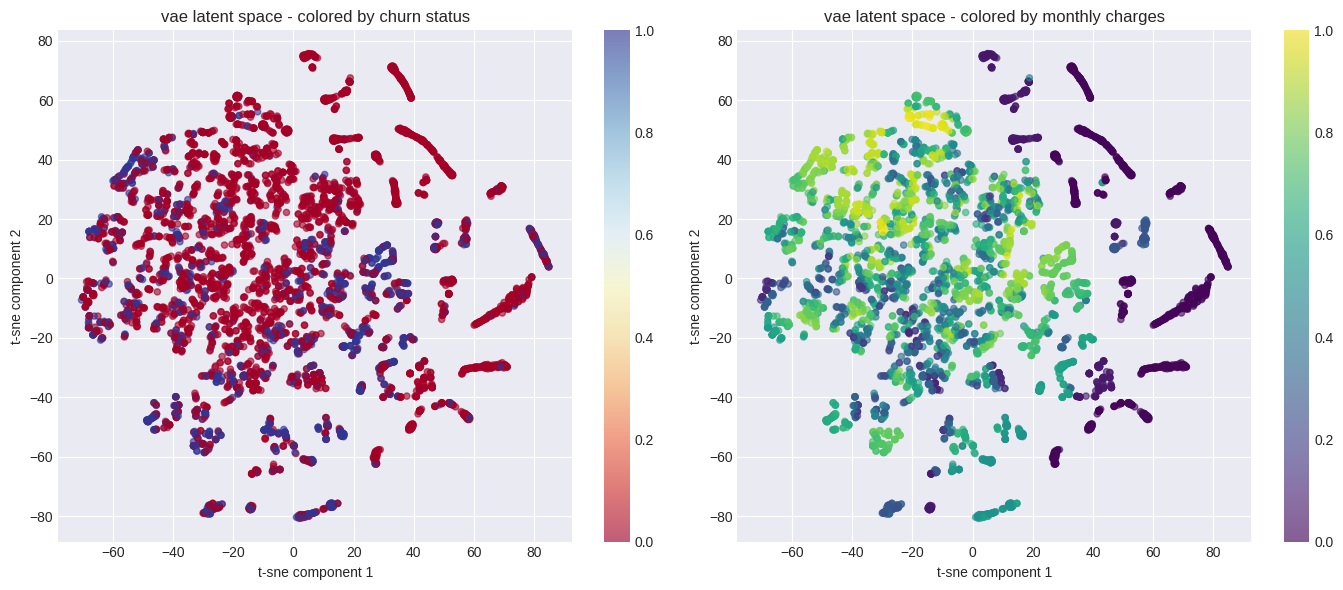

latent space visualization complete


In [36]:
# visualize vae latent space
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# get latent representations
vae.eval()
with torch.no_grad():
    all_latent = vae.get_latent_representation(X_train_tensor).cpu().numpy()

# apply t-sne for 2d visualization
print("computing t-sne embedding")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(all_latent)

# create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plot 1: latent space colored by churn
scatter1 = axes[0].scatter(latent_2d[:, 0], latent_2d[:, 1],
                           c=y_train, cmap='RdYlBu', alpha=0.6, s=20)
axes[0].set_title('vae latent space - colored by churn status')
axes[0].set_xlabel('t-sne component 1')
axes[0].set_ylabel('t-sne component 2')
plt.colorbar(scatter1, ax=axes[0])

# plot 2: latent space colored by monthly charges
monthly_charges_normalized = (df_processed.loc[y_train.index, 'MonthlyCharges'] -
                             df_processed.loc[y_train.index, 'MonthlyCharges'].min()) / \
                            (df_processed.loc[y_train.index, 'MonthlyCharges'].max() -
                             df_processed.loc[y_train.index, 'MonthlyCharges'].min())

scatter2 = axes[1].scatter(latent_2d[:, 0], latent_2d[:, 1],
                           c=monthly_charges_normalized, cmap='viridis', alpha=0.6, s=20)
axes[1].set_title('vae latent space - colored by monthly charges')
axes[1].set_xlabel('t-sne component 1')
axes[1].set_ylabel('t-sne component 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

print("latent space visualization complete")

compare feature importance for traditional, VAE-latent, and combined feature sets to see how much the model relies on deep vs original features.


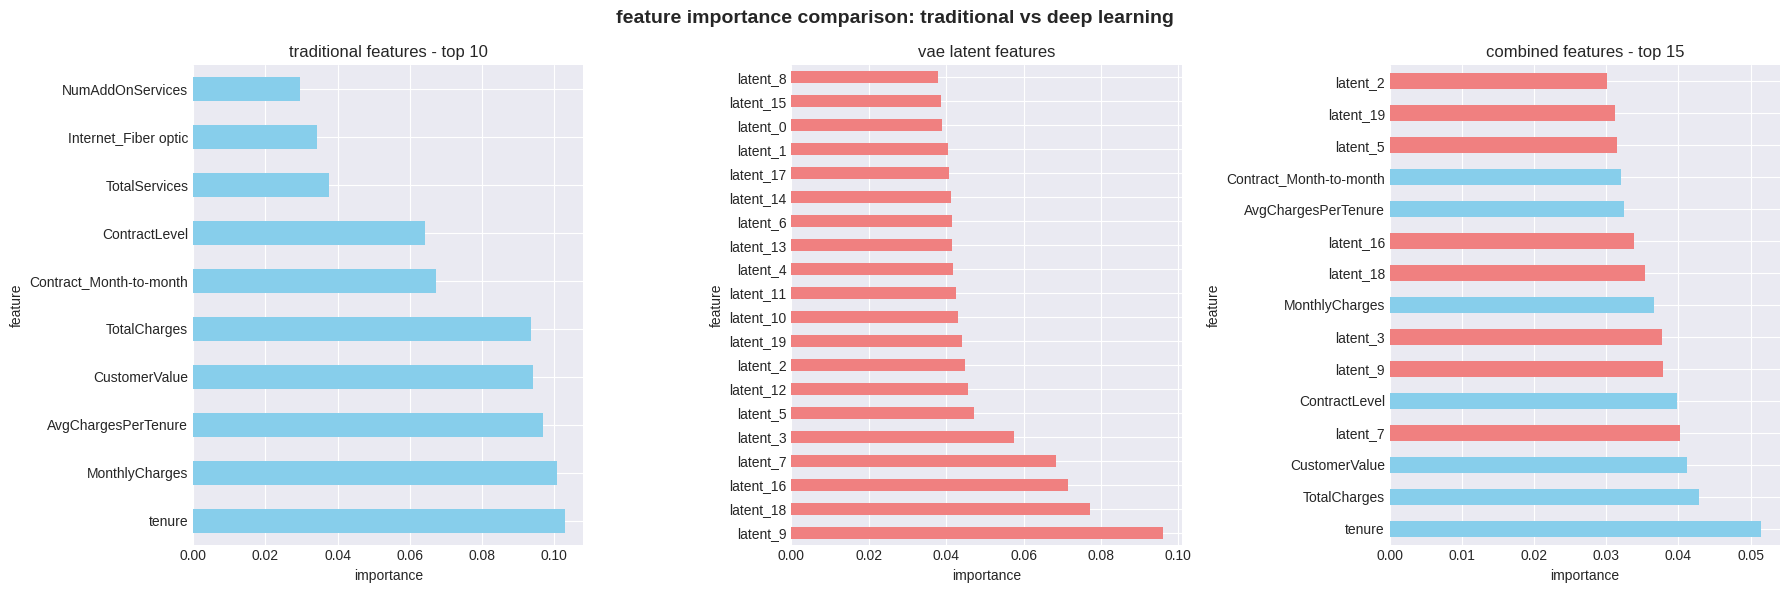


feature contribution in combined model:
traditional features: 0.277
vae latent features: 0.278
latent/traditional ratio: 1.00


In [37]:
# compare feature importance: original vs vae-enhanced
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# traditional features importance
rf_traditional = RandomForestClassifier(random_state=42, n_estimators=100)
rf_traditional.fit(X_train_balanced, y_train_balanced)

traditional_importance = pd.DataFrame({
    'feature': X_train_balanced.columns,
    'importance': rf_traditional.feature_importances_
}).sort_values('importance', ascending=False).head(10)

traditional_importance.plot(x='feature', y='importance', kind='barh',
                           ax=axes[0], color='skyblue', legend=False)
axes[0].set_title('traditional features - top 10')
axes[0].set_xlabel('importance')

# 2. vae latent features importance
rf_latent = RandomForestClassifier(random_state=42, n_estimators=100)
rf_latent.fit(X_train_latent, y_train)

latent_importance = pd.DataFrame({
    'feature': X_train_latent.columns,
    'importance': rf_latent.feature_importances_
}).sort_values('importance', ascending=False)

latent_importance.plot(x='feature', y='importance', kind='barh',
                      ax=axes[1], color='lightcoral', legend=False)
axes[1].set_title('vae latent features')
axes[1].set_xlabel('importance')

# 3. combined features importance
rf_combined = RandomForestClassifier(random_state=42, n_estimators=100)
rf_combined.fit(X_train_combined, y_train)

# separate traditional vs latent in combined
combined_importance = pd.DataFrame({
    'feature': X_train_combined.columns,
    'importance': rf_combined.feature_importances_,
    'type': ['traditional' if 'latent' not in col else 'latent'
             for col in X_train_combined.columns]
}).sort_values('importance', ascending=False).head(15)

# color by type
colors = ['skyblue' if t == 'traditional' else 'lightcoral'
          for t in combined_importance['type']]
combined_importance.plot(x='feature', y='importance', kind='barh',
                        ax=axes[2], color=colors, legend=False)
axes[2].set_title('combined features - top 15')
axes[2].set_xlabel('importance')

plt.suptitle('feature importance comparison: traditional vs deep learning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# analyze contribution of latent features
latent_contribution = combined_importance[combined_importance['type'] == 'latent']['importance'].sum()
traditional_contribution = combined_importance[combined_importance['type'] == 'traditional']['importance'].sum()

print(f"\nfeature contribution in combined model:")
print(f"traditional features: {traditional_contribution:.3f}")
print(f"vae latent features: {latent_contribution:.3f}")
print(f"latent/traditional ratio: {latent_contribution/traditional_contribution:.2f}")